In [1]:
%load_ext autoreload
%autoreload 2

import os
import json
import cv2
import numpy as np
import torch
import glob
import torch.nn as nn

import tqdm # For progress bars

from yolo.yolo import Yolo

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device('cuda')
print(device)

mps


In [3]:
class_dict = {
    'Head': 0,
    'RShoulder': 1,
    'LShoulder': 2,
    'LElbow': 3,
    'LWrist': 4,
    'RHip': 5,
    'LHip': 6,
    'LKnee': 7,
    'RKnee': 8,
    'RAnkle': 9,
    'LAnkle': 10,
    'RElbow': 11,
    'RWrist': 12,
    'Neck': 13
}

In [4]:
def Json_to_yolo_formate(json_data, img_width, img_height):
    yolo_data = []
    for shape in json_data['shapes']:
        x1, y1 = shape['points'][0]
        x2, y2 = shape['points'][1]
        x_left = x1 / img_width
        y_top = y1 / img_height
        width = (x2 - x1) / img_width
        height = (y2 - y1) / img_height
        class_id = class_dict[shape['label']]
        yolo_data.append([class_id, x_left, y_top, width, height])
    return yolo_data

def save_yolo_formate(json_data):
    image_name = json_data['imagePath'].split('.')[0]
    image_path = f"./dataset/{image_name}.png"
#     print(image_path)
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    yolo_data = Json_to_yolo_formate(json_data, w, h)
    directory = './dataset/annotation_percentage/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    with open (f'{directory}{image_name}.txt', 'w') as f:
        for data in yolo_data:
            f.write(' '.join(map(str, data)) + '\n')

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2

normal_size = (128,128)

def load_image(path):
    return cv2.imread(path)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def crop_image(image, coords):
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    return image[int(y1):int(y2), int(x1):int(x2)]

def show_image_detail(image, json):
    plt.imshow(image)
    fig, axs = plt.subplots(1, len(json['shapes']), figsize=(15, 15))
    for i, shape in enumerate(json['shapes']):
        croped_test_img = crop_image(image, shape['points'])
        croped_test_img = resize_image(croped_test_img)
        print(croped_test_img.shape)
        axs[i].imshow(croped_test_img)
        axs[i].set_title(shape['label'])
    plt.show()

def resize_image(image, size=normal_size):
    return cv2.resize(image, size)

def vaildate_yolo_formate(path):
    imag = cv2.imread(path)
    yolo_path = os.path.join('dataset', 'annotation_percentage', os.path.basename(path).split('.')[0] + '.txt')
    with open(yolo_path, 'r') as boxes:
        for box in boxes:
            box = box.split(' ')
            class_id, x_center, y_center, width, height = map(float, box)
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            cv2.rectangle(imag, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(imag, str(int(class_id)), (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 5)
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    plt.imshow(imag)
    plt.show()

In [6]:
# json_paths = glob.glob('dataset/*.json')
# for json_path in tqdm.tqdm(json_paths):
#     json_data = load_json(json_path)
#     save_yolo_formate(json_data)

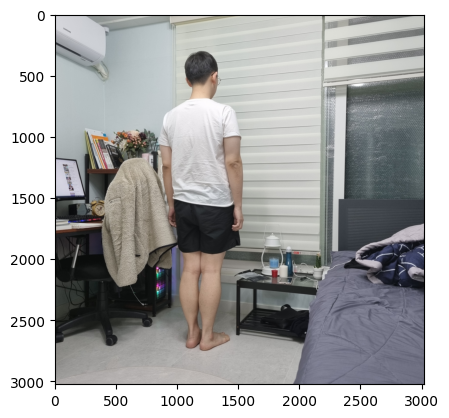

In [7]:
vaildate_yolo_formate('dataset/stand_b_74.png')

In [8]:
def iou(boxes1, boxes2): # box = [x_center, y_center, width, height]
    ious = []
    for box1, box2 in zip(boxes1, boxes2):
        x11, y11, x12, y12 = box1[0] - box1[2]/2, box1[1] - box1[3]/2, box1[0]  + box1[2]/2, box1[1] + box1[3]/2
        x21, y21, x22, y22 = box2[0] - box2[2]/2, box2[1] - box2[3]/2, box2[0]  + box2[2]/2, box2[1] + box2[3]/2

        x_inter1, y_inter1 = max(x11, x21), max(y11, y21)
        x_inter2, t_inter2 = min(x12, x22), min(y12, y22)

        intersection = abs(x_inter2 - x_inter1) * abs(y_inter1 - t_inter2)

        box1_area, box2_area = box1[2] * box1[3], box2[2] * box2[3]
        ious.append(intersection / (box1_area + box2_area - intersection))
    return ious

box1 = [[1, 1, 2, 2], [1, 1, 2, 2]]
box2 = [[2, 1, 2, 2], [3,1,2,2]]
test = iou(box1, box2)
print(test)
    

[0.3333333333333333, 0.0]


In [9]:
box1 = [1,1,2,2]
box2 = [2,1,2,2]
print(iou([box1], [box2]))

[0.3333333333333333]


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
class backDataset(Dataset):
    def __init__(self, transform=None, anchor_boxes = None):
        self.img_paths = glob.glob('dataset/*.png')
        self.transform = transform
        self.anchor_boxes = anchor_boxes * (416/1920)
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        original_h, original_w = img.shape[:2]
        normalize = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((416, 416)),
            transforms.ToTensor()
        ])
        with open(os.path.join('dataset', 'annotation_percentage', os.path.basename(self.img_paths[idx]).replace('.png', '.txt'))) as f:
            all_boxes = []
            for line in f.readlines():
                class_id, px, py, pw, ph = map(float, line.strip().split(' ')) # class_id, % x, % y, % w, % h
                
                boxes = []
                for scale in [13, 26, 52]:
                    new_box = torch.zeros(25) # create tensor with 4 + 1 + 14 length + 2 (for px, py)

                    # Assign basic values that no need to compute (..., obj, ..., class, ...)
                    new_box[4] = 1  # Automatically at 1.0 because obv. object
                    new_box[int(class_id + 5)] = 1
                    new_box[-2] = pw
                    new_box[-1] = ph

                    # Assign center offset percentage
                    new_box[-4] = px + (pw / 2) # Set x position percentage to gt_bb center
                    new_box[-3] = py + (ph / 2) # Set y position percentage to gt_bb center
                    
                    # Assign raw tw, th offset
                    new_box[[2, 3]] = torch.tensor([pw * scale, ph * scale])
                    
                    # Compute tx, ty based on raw coordinate offset
                    raw_coord = torch.tensor([new_box[-4] * scale, new_box[-3] * scale])
                    cell_coord = raw_coord // 1
                    new_box[[0, 1]] = raw_coord - cell_coord
                    
                    # Get best anchor for this scale                    
                    best_anchor = [None, -1]  # [[anchor_w, anchor_h]_scaled, anchor_iou]
                    for anchor in self.anchor_boxes:
                        anchor_iou = iou([[0, 0, new_box[2], new_box[3]]], [[0, 0] + (anchor / scale).tolist()])
                        if anchor_iou[0] > best_anchor[1]:
                            best_anchor = [anchor / scale, anchor_iou[0]]
                    new_box[[-6, -5]] = best_anchor[0]
                    
                    # Adjust raw tw, th to real tw th
#                     print(new_box[[2, 3]], '|', best_anchor[0], '|', new_box[[2, 3]] / best_anchor[0])
                    new_box[[2, 3]] = new_box[[2, 3]] / best_anchor[0] # This will give the exp(tw) and exp(th) to get from anchor to gt

                    boxes.append(new_box)
                all_boxes.append(torch.stack(boxes))
#                 print(all_boxes[-1])
        img = normalize(img)
        return img, torch.stack(all_boxes)

From the above, the expected output is a size `23` vector that mimics the vector expected from predictions.  

Expected shape is `[num_boxes_img, 3 (num_scales), bounding_box_vector]`. The first two sizes are self explanatory. 
The last size is the `23` size bounding box vector relative to an anchor box that was assigned. The elements are:  
`[tx, ty, exp(tw), exp(th), obj, ...classes probs... x 14, aw, wh, px, py, pw, ph]` such that `px, py`, `pw, ph` are the percentage coordinates to center of cell and w/h of the ground truth bounding box. `aw, ah` is the assigned anchor box's width and height (already scaled) (may remove if not needed). `tx, ty, tw, th` are the absolutes, i.e. `tx` is `tx` away from the left of the cell, `tw` is the width of the bounding box times `tw`.

For extracting information, make sure to use `box[:19]` to not get the last 4 meta data elements (unless needed).

Example:  
`torch.Size([14, 3, 23])`  

This means `14` boxes in img, for each box, there's a size `23` vector for each of the `3` scales. **The scales are already computed, no need to scale again**

In [11]:
def show_img_box(img, data):
    tmp_img = img.permute(1, 2, 0)
    tmp_img = cv2.cvtColor(tmp_img.numpy(), cv2.COLOR_BGR2RGB)
    for box in data:
        class_id = torch.argmax(box[0][5:19])
        box_dim = (box[0][[-2, -1]] * 416)
        x1, y1 = (box[0][[-4, -3]] * 416) - (box_dim / 2) 
        x2, y2 = (box[0][[-4, -3]] * 416) + (box_dim / 2) 
        cv2.rectangle(tmp_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(tmp_img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
    plt.imshow(tmp_img)


In [12]:
anchors = torch.tensor([[151.37092679, 151.37092679], [116.1775567, 116.1775567 ], [ 69.10933737,  69.10933737], 
                        [206.27557981, 206.27557981], [257.97346109, 257.97346109]])

In [13]:
test_loader = DataLoader(backDataset(anchor_boxes=anchors), batch_size=1, shuffle=True)

In [14]:
img, data = test_loader.dataset[0]

In [15]:
print(data.shape)
data[0]

torch.Size([10, 3, 25])


tensor([[0.2639, 0.0658, 1.1017, 1.1017, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.1518, 1.1518, 0.4818, 0.1589, 0.0976, 0.0976],
        [0.5278, 0.1317, 1.1806, 1.1806, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 2.1498, 2.1498, 0.4818, 0.1589, 0.0976, 0.0976],
        [0.0556, 0.2633, 4.7224, 4.7224, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.0749, 1.0749, 0.4818, 0.1589, 0.0976, 0.0976]])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


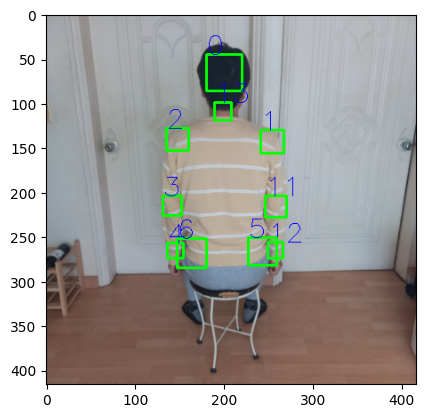

In [16]:
show_img_box(img, data)

In [17]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

def collate_fn(batch): # each item in batch is (x, y)
    img = [item[0] for item in batch]
    boxes = [item[1] for item in batch]
    max_boxes = max([len(box) for box in boxes])
    boxes_list_padded = []
    for box in boxes:
        if box.shape[0] < max_boxes:
            box = torch.cat([box, torch.zeros(max_boxes - box.shape[0], box.shape[1], box.shape[2])])
        boxes_list_padded.append(box)
    return torch.stack(img), torch.stack(boxes_list_padded)


dataset = backDataset(anchor_boxes=anchors)
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)

In [18]:
test_train_img, test_train_data = next(iter(train_loader))
print(test_train_img.shape)
print(test_train_data.shape)

Invalid SOS parameters for sequential JPEG


torch.Size([10, 3, 416, 416])
torch.Size([10, 14, 3, 25])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


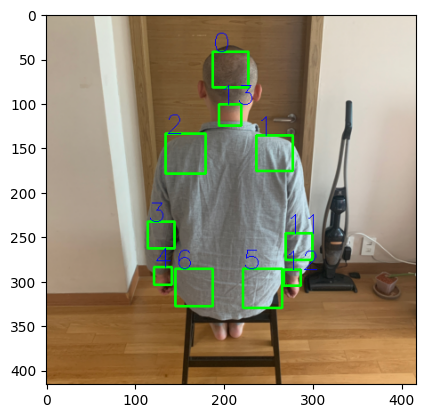

In [19]:
show_img_box(test_train_img[0], test_train_data[0])

# YOLO
Yolov3 (might be easier)
https://blog.paperspace.com/how-to-implement-a-yolo-object-detector-in-pytorch/
https://arxiv.org/abs/1804.02767

In [20]:
tt, td = next(iter(train_loader))

Invalid SOS parameters for sequential JPEG


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


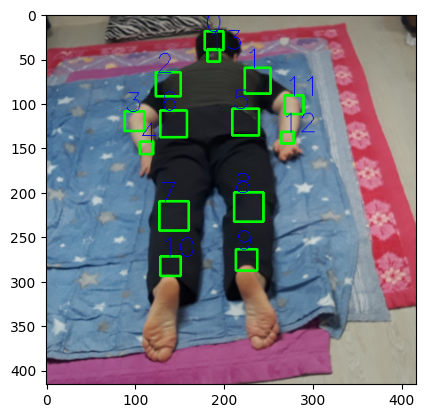

In [21]:
show_img_box(tt[0], td[0])
# for img, data in zip(tt, td):
#     show_img_box(img, data)

In [36]:
tt.shape

torch.Size([10, 3, 416, 416])

In [37]:
yolo_test = Yolo(14, anchors.shape[0]).to(device)

In [38]:
tt = tt.to(device)
test_result = yolo_test(tt)
# test_result = [result.permute(0, 2, 3, 1) for result in test_result] # need to permute to (x, y, 95) b/c 95 is layers, not prediciton list as wanted

In [25]:
print(test_result[0].shape)
test_layer = test_result[0].permute(0, 3, 1, 2)
test_layer = test_layer.reshape(10,5,19,13, 13)
test_layer2 = test_layer[:, :, 0, :,:]
print(test_layer2.shape)


torch.Size([10, 13, 13, 95])
torch.Size([10, 5, 13, 13])


In [188]:
class MultiFactorLoss(nn.Module):
    def __init__(self, num_anchors, batch_avg=False):
        super().__init__()
        self.num_anchors = num_anchors
        self.batch_avg = batch_avg        
        
        self.mseloss = nn.MSELoss()
        
    def bounding_loss(self, anchors, ground_truths, img_scale, scale_dim):
        anchors = anchors // (416 // scale_dim)
#         img_scale = img_scale.permute(1, 2, 0)
#         img_scale = img_scale.view(95, -1)  # DEBUG: temp flatten for testing
#         print(img_scale.shape)

        # Get relevant cell coordinates
        ground_truths = ground_truths[ground_truths[:, 4] != 0] # Use only the ones with objectness = 1 (0 is from padding)
        cell_coords = ((ground_truths[:, [-4, -3]] * scale_dim) - 1).int() # gt % x y * 13 (etc) = pixel position; int = cell position
#         cell_coords = cell_coords[:, 0] * scale_dim + cell_coords[:, 1] # Convert to flattened idx

        relevant_preds = img_scale[:, cell_coords[:, 0], cell_coords[:, 1]]
        relevant_preds = torch.stack(torch.split(relevant_preds, 19, dim=0))

        # Broadcast sig and exp across each layer
        relevant_preds[:, [0, 1], :] = torch.sigmoid(relevant_preds[:, [0, 1], :])
        relevant_preds[:, [2, 3], :] = torch.exp(relevant_preds[:, [2, 3], :])

        # Convert to [cell, anchor, features]
        relevant_preds = relevant_preds.permute(0, 2, 1)
#         relevant_preds = relevant_preds.permute(2, 0, 1)
#         print(relevant_preds.shape)
#         print(relevant_preds[:, :, :4].shape)

        # Compute MSE Losses
#         print(ground_truths.shape)
#         print(ground_truths[:, :4])
#         print(torch.flatten(ground_truths[:, :4]).shape)
#         test = ground_truths.repeat(self.num_anchors, 1, 1)
#         print(test[:, :, :4].shape, relevant_preds[:, :, :4].shape)
#         loss_compare = [test[:, :, :4], relevant_preds[:, :, :4]]

        
        # DEBUG: Keeping to compare performance
#         mse_losses = []
#         for pred in relevant_preds:
#             for box in pred:
# #                 print(box.shape)
#                 mse_losses.append(torch.sum(torch.tensor([self.mseloss(box[0:4], gt[0:4]) for gt in ground_truths])))
        
#         return torch.mean(torch.tensor(mse_losses))
        return self.mseloss(ground_truths.repeat(self.num_anchors, 1, 1)[:, :, :4],
                            relevant_preds[:, :, :4])

    def forward(self, anchors, true_y, pred_y):
        '''
        Loss function for bounding boxes. 
        Assumes predict_boxes in shape [b, x, y, c]. 
        Assumes ground_truths to be original resolution. Loss function will down scale.
        '''
#         print(true_y.shape)
        ground_truths = true_y.permute(2, 0, 1, 3) # Permute to cluster into scales for zipping
#         print(ground_truths.shape)
        
        total_loss = 0
        for scale_dim, gts, img_scales in zip([13, 26, 52], ground_truths, pred_y):   # iterate through each scale
#             print(f'Scale: 416x416 -> {scale_dim}x{scale_dim}')
#             print(img_scales.shape)
#             print(gts.shape)
            losses = []
            for image, image_gt in zip(img_scales, gts):
                losses.append(self.bounding_loss(anchors, image_gt.to('cpu'), image.to('cpu'), scale_dim))
                
            losses = torch.tensor(losses)
            losses = torch.mean(losses) if self.batch_avg else torch.sum(losses)
                
            total_loss += losses
#         print(total_loss)
        return total_loss

In [189]:
criterion = MultiFactorLoss(5, batch_avg=True)
criterion(anchors, td, test_result)

tensor(2.9525)

In [32]:
def train(model, optimizer, loss_fn, epochs=10):
    model = model.to(device=device)
    for epoch in tqdm.tqdm(range(epochs)):
        for i, (x, ground_truths) in enumerate(train_loader):
            x = x.to(device)
            ground_truths = ground_truths.to(device)
            
            y = model(x)
            loss = loss_fn(anchors, ground_truths, y)
            
            if i % 100 == 0:
                print(f'Epoch: {epoch}, Iteration: {i}, loss: {loss}')

            # Delete stuff to free up resources
            del x
            del ground_truths
            del y
            del loss

In [33]:
model = Yolo(14, 5, debug=False)
optimizer = torch.optim.Adam(params=model.parameters())
train(model, optimizer, MultiFactorLoss(batch_avg=True))

  0%|                                                                                                                                              | 0/10 [00:00<?, ?it/s]

Epoch: 0, Iteration: 0, loss: 27.681354522705078


Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
 10%|█████████████▎                                                                                                                       | 1/10 [02:10<19:32, 130.28s/it]

Epoch: 1, Iteration: 0, loss: 30.803237915039062


Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
 20%|██████████████████████████▌                                                                                                          | 2/10 [04:20<17:23, 130.42s/it]

...

Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▍                          | 8/10 [17:23<04:20, 130.39s/it]Invalid SOS parameters for sequential JPEG


Epoch: 8, Iteration: 0, loss: 32.579185485839844


Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋             | 9/10 [19:33<02:10, 130.48s/it]Invalid SOS parameters for sequential JPEG


Epoch: 9, Iteration: 0, loss: 33.7183837890625


Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [21:43<00:00, 130.39s/it]


In [29]:
test_result[0].shape

torch.Size([10, 13, 13, 95])

Expected prediction structure `[tx, ty, tw, tl, obj, c1, c2, ..., c14]`

In [30]:
td[4]

tensor([[[0.1532, 0.3649, 1.0121,  ..., 0.1050, 0.0897, 0.0897],
         [0.3065, 0.7299, 1.0845,  ..., 0.1050, 0.0897, 0.0897],
         [0.6129, 0.4597, 4.3380,  ..., 0.1050, 0.0897, 0.0897]],

        [[0.3265, 0.5716, 0.6164,  ..., 0.1978, 0.0546, 0.0546],
         [0.6529, 0.1432, 1.1256,  ..., 0.1978, 0.0546, 0.0546],
         [0.3058, 0.2864, 2.6420,  ..., 0.1978, 0.0546, 0.0546]],

        [[0.9460, 0.6208, 0.6849,  ..., 0.2785, 0.0607, 0.0607],
         [0.8920, 0.2415, 0.9178,  ..., 0.2785, 0.0607, 0.0607],
         [0.7840, 0.4830, 2.9355,  ..., 0.2785, 0.0607, 0.0607]],

        ...,

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

 

In [ ]:
bounding_loss(ab, td[4], test_result)

In [ ]:
a = torch.randn(5)
b = torch.randn(5)
c = torch.randn(5)

torch.stack([a, b, c])

In [ ]:
print(a, b, c)

In [ ]:
bounding_loss(ab, td[4], test_result)

In [ ]:
a = torch.randn(5)
b = torch.randn(5)
c = torch.randn(5)

torch.stack([a, b, c])

tensor([[ 0.2585,  1.3519, -0.6721,  0.5296,  0.7463],
        [-0.8977,  1.3145,  1.2127,  0.4994, -1.3664],
        [ 1.3070,  1.1590,  0.3500, -0.5008, -0.2213]])

In [ ]:
print(a, b, c)

tensor([ 0.2585,  1.3519, -0.6721,  0.5296,  0.7463]) tensor([-0.8977,  1.3145,  1.2127,  0.4994, -1.3664]) tensor([ 1.3070,  1.1590,  0.3500, -0.5008, -0.2213])


In [172]:
def function_to_grid(ground_truths,S):
    output_size = [13, 26, 52]
    S_dim = output_size[S]
    return torch.round(ground_truths[:,:,S,-4:-2] * S_dim).long()

    
def one_hot_coordinate(ground_truths,S):
    output_size = [13, 26, 52]
    S_dim = output_size[S]
    grid_have_stuff = function_to_grid(ground_truths,S)
    one_hot = torch.zeros(10,S_dim,S_dim)
    for i in range(10):
        one_hot[i,grid_have_stuff[i,:,1],grid_have_stuff[i,:,0]] = 1
    return one_hot

import torch
import torch.nn.functional as F

def obj_loss(pred, target):
    pred0 = pred[0][:,:,:,4].reshape(-1)
    pred1 = pred[1][:,:,:,4].reshape(-1)
    pred2 = pred[2][:,:,:,4].reshape(-1)
    OH_gt0 = one_hot_coordinate(target,0).reshape(-1)
    OH_gt1 = one_hot_coordinate(target,1).reshape(-1)
    OH_gt2 = one_hot_coordinate(target,2).reshape(-1)
    
    # Apply sigmoid activation to the raw predictions
    pred0 = torch.sigmoid(pred0)
    pred1 = torch.sigmoid(pred1)
    pred2 = torch.sigmoid(pred2)
    
    # Compute the binary cross entropy loss
    loss = F.binary_cross_entropy(pred0, OH_gt0)
    loss += F.binary_cross_entropy(pred1, OH_gt1)
    loss += F.binary_cross_entropy(pred2, OH_gt2)
    
    return loss


loss = obj_loss(test_result, td)


In [173]:
print(loss)

tensor(2.3085, grad_fn=<AddBackward0>)


In [187]:
def function_to_grid(ground_truths,S):
    output_size = [13, 26, 52]
    S_dim = output_size[S]
    return torch.round(ground_truths[:,:,S,-4:-2] * S_dim).long()

    
def one_hot_coordinate(ground_truths,S):
    output_size = [13, 26, 52]
    S_dim = output_size[S]
    grid_have_stuff = function_to_grid(ground_truths,S)
    one_hot = torch.zeros(10,S_dim,S_dim)
    for i in range(10):
        one_hot[i,grid_have_stuff[i,:,1],grid_have_stuff[i,:,0]] = 1
    return one_hot

import torch
import torch.nn.functional as F

def obj_loss(pred, target):
    pred0 = pred[0].reshape(10, 13, 13, -1, 19)
    pred1 = pred[1].reshape(10, 26, 26, -1, 19)
    pred2 = pred[2].reshape(10, 52, 52, -1, 19)
    pred0 = pred0[:,:,:,:,4].reshape(-1)
    pred1 = pred1[:,:,:,:,4].reshape(-1)
    pred2 = pred2[:,:,:,:,4].reshape(-1)

    OH_gt0 = one_hot_coordinate(target,0).reshape(-1).repeat(5)
    OH_gt1 = one_hot_coordinate(target,1).reshape(-1).repeat(5)
    OH_gt2 = one_hot_coordinate(target,2).reshape(-1).repeat(5)
    
    # Apply sigmoid activation to the raw predictions
    pred0 = torch.sigmoid(pred0)
    pred1 = torch.sigmoid(pred1)
    pred2 = torch.sigmoid(pred2)
    
    # Compute the binary cross entropy loss
    loss = F.binary_cross_entropy(pred0, OH_gt0)
    loss += F.binary_cross_entropy(pred1, OH_gt1)
    loss += F.binary_cross_entropy(pred2, OH_gt2)
    
    return loss


loss = obj_loss(test_result, td)

In [188]:
loss

tensor(2.2574, grad_fn=<AddBackward0>)

In [ ]:
del test_result
del tt